In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch.serialization import safe_globals

project_root = Path.cwd().resolve().parent
data_dir = project_root / "data"

train_data = torch.load(data_dir / "train.pt", weights_only=False)
test_data = torch.load(data_dir / "test.pt", weights_only=False)
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")

print(type(train_data))
print(type(test_data))
print(len(train_data), len(test_data))
print(train_data[0])
print(test_data[0])

print(sample_submission.head())
print(sample_submission.columns)

<class 'list'>
<class 'list'>
20000 2000
Data(x=[16, 11], edge_index=[2, 32], edge_attr=[32, 4], y=3.557, pos=[16, 3], name='gdb_32041')
Data(x=[21, 11], edge_index=[2, 42], edge_attr=[42, 4], y=0.0, pos=[21, 3], name='gdb_59377')
         Idx  labels
0  gdb_59377  1.0001
1  gdb_14632  1.0001
2  gdb_35326  1.0001
3  gdb_11448  1.0001
4  gdb_35889  1.0001
Index(['Idx', 'labels'], dtype='object')


In [32]:
def summarize_graph_list(graph_list, has_labels=True):
    rows = []

    for g in graph_list:
        row = {
            "name": g.name,
            "num_nodes": g.num_nodes,
            "num_edges": g.edge_index.shape[1],
            "node_feat_dim": g.x.shape[1] if g.x is not None else 0,
            "edge_feat_dim": g.edge_attr.shape[1] if g.edge_attr is not None else 0,
            "has_pos": g.pos is not None,
            "pos_dim": g.pos.shape[1] if g.pos is not None else 0,
        }

        if has_labels:
            y = g.y.item() if torch.is_tensor(g.y) else float(g.y)
            row["y"] = y

        rows.append(row)

    return pd.DataFrame(rows)


train_df = summarize_graph_list(train_data, has_labels=True)
test_df = summarize_graph_list(test_data, has_labels=False)

train_df.head()

,name,num_nodes,num_edges,node_feat_dim,edge_feat_dim,has_pos,pos_dim,y
0,gdb_32041,16,32,11,4,True,3,3.5570
1,gdb_58827,20,44,11,4,True,3,1.4097
2,gdb_47779,16,32,11,4,True,3,7.0329
3,gdb_110081,17,34,11,4,True,3,3.9775
4,gdb_106469,19,40,11,4,True,3,2.0716


In [33]:
print("Train summary")
print(train_df.describe(include="all"))

print("\nTest summary")
print(test_df.describe(include="all"))

Train summary
             name     num_nodes     num_edges  node_feat_dim  edge_feat_dim  \
count       20000  20000.000000  20000.000000        20000.0        20000.0   
unique      20000           NaN           NaN            NaN            NaN   
top     gdb_32041           NaN           NaN            NaN            NaN   
freq            1           NaN           NaN            NaN            NaN   
mean          NaN     18.009700     37.209000           11.0            4.0   
std           NaN      2.951058      6.318126            0.0            0.0   
min           NaN      4.000000      6.000000           11.0            4.0   
25%           NaN     16.000000     34.000000           11.0            4.0   
50%           NaN     18.000000     38.000000           11.0            4.0   
75%           NaN     20.000000     42.000000           11.0            4.0   
max           NaN     29.000000     56.000000           11.0            4.0   

       has_pos  pos_dim             y

In [34]:
print("Unique node feature dims in train:", train_df["node_feat_dim"].unique())
print("Unique edge feature dims in train:", train_df["edge_feat_dim"].unique())
print("Unique pos dims in train:", train_df["pos_dim"].unique())

print("Any missing names in train:", train_df["name"].isnull().any())
print("Any missing names in test:", test_df["name"].isnull().any())

print("Sample submission size:", sample_submission.shape)
print("Unique sample submission IDs:", sample_submission["Idx"].nunique())
print("Unique test graph names:", test_df["name"].nunique())
print("Submission IDs match test names exactly:", set(sample_submission["Idx"]) == set(test_df["name"]))

Unique node feature dims in train: [11]
Unique edge feature dims in train: [4]
Unique pos dims in train: [3]
Any missing names in train: False
Any missing names in test: False
Sample submission size: (2000, 2)
Unique sample submission IDs: 2000
Unique test graph names: 2000
Submission IDs match test names exactly: True


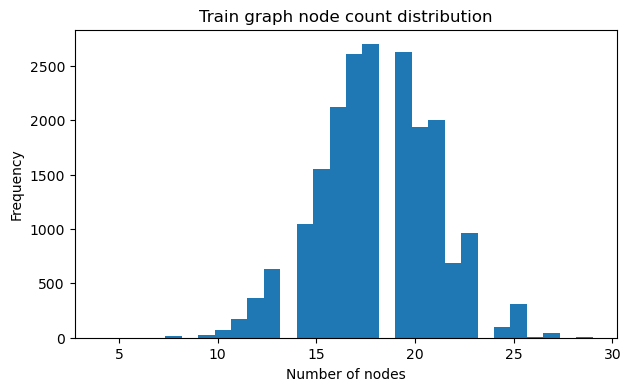

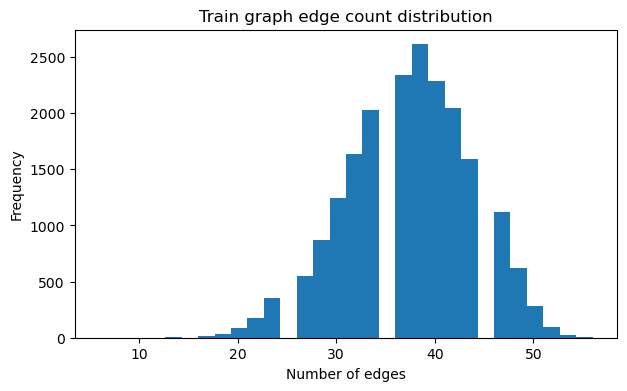

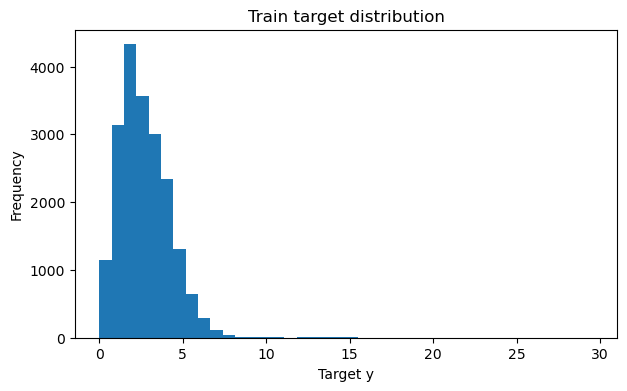

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_df["num_nodes"], bins=30)
ax.set_title("Train graph node count distribution")
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Frequency")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_df["num_edges"], bins=30)
ax.set_title("Train graph edge count distribution")
ax.set_xlabel("Number of edges")
ax.set_ylabel("Frequency")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_df["y"], bins=40)
ax.set_title("Train target distribution")
ax.set_xlabel("Target y")
ax.set_ylabel("Frequency")
plt.show()

In [36]:
node_feature_matrix = torch.cat([g.x for g in train_data], dim=0)
edge_feature_matrix = torch.cat([g.edge_attr for g in train_data], dim=0)
pos_matrix = torch.cat([g.pos for g in train_data], dim=0)

print("Node feature shape:", tuple(node_feature_matrix.shape))
print("Edge feature shape:", tuple(edge_feature_matrix.shape))
print("Pos shape:", tuple(pos_matrix.shape))

print("\nNode feature means")
print(node_feature_matrix.mean(dim=0))

print("\nNode feature stds")
print(node_feature_matrix.std(dim=0))

print("\nEdge feature means")
print(edge_feature_matrix.mean(dim=0))

print("\nEdge feature stds")
print(edge_feature_matrix.std(dim=0))

print("\nPos means")
print(pos_matrix.mean(dim=0))

print("\nPos stds")
print(pos_matrix.std(dim=0))

Node feature shape: (360194, 11)
Edge feature shape: (744180, 4)
Pos shape: (360194, 3)

Node feature means
tensor([5.1169e-01, 3.5115e-01, 5.8177e-02, 7.7522e-02, 1.4603e-03, 3.6592e+00,
        4.8790e-02, 3.0681e-02, 1.3730e-01, 3.2033e-01, 1.6305e-02])

Node feature stds
tensor([0.4999, 0.4773, 0.2341, 0.2674, 0.0382, 2.7738, 0.2154, 0.1725, 0.3442,
        0.4666, 0.1415])

Edge feature means
tensor([0.9047, 0.0328, 0.0148, 0.0476])

Edge feature stds
tensor([0.2936, 0.1782, 0.1209, 0.2129])

Pos means
tensor([ 0.0820, -0.3397,  0.0699])

Pos stds
tensor([1.6597, 1.9872, 1.4437])


               num_nodes  num_edges  graph_density         y
num_nodes       1.000000   0.951199       0.005674 -0.367239
num_edges       0.951199   1.000000       0.310233 -0.411377
graph_density   0.005674   0.310233       1.000000 -0.182952
y              -0.367239  -0.411377      -0.182952  1.000000


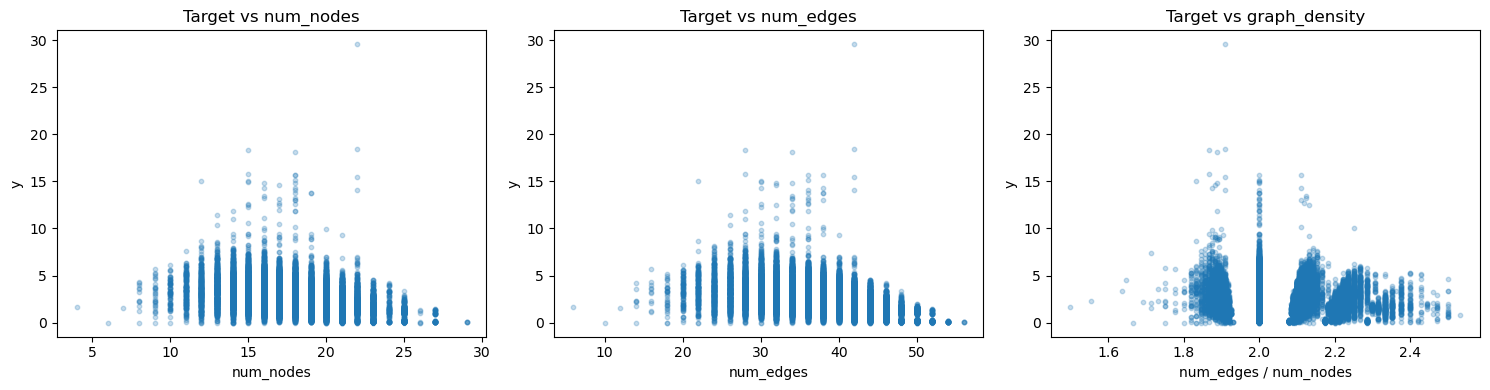

In [37]:
train_stats = pd.DataFrame(
    [
        {
            "name": g.name,
            "num_nodes": g.num_nodes,
            "num_edges": g.edge_index.shape[1],
            "y": float(g.y),
        }
        for g in train_data
    ]
)

train_stats["graph_density"] = train_stats["num_edges"] / train_stats["num_nodes"]

print(train_stats[["num_nodes", "num_edges", "graph_density", "y"]].corr(numeric_only=True))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(train_stats["num_nodes"], train_stats["y"], alpha=0.25, s=10)
axes[0].set_title("Target vs num_nodes")
axes[0].set_xlabel("num_nodes")
axes[0].set_ylabel("y")

axes[1].scatter(train_stats["num_edges"], train_stats["y"], alpha=0.25, s=10)
axes[1].set_title("Target vs num_edges")
axes[1].set_xlabel("num_edges")
axes[1].set_ylabel("y")

axes[2].scatter(train_stats["graph_density"], train_stats["y"], alpha=0.25, s=10)
axes[2].set_title("Target vs graph_density")
axes[2].set_xlabel("num_edges / num_nodes")
axes[2].set_ylabel("y")

plt.tight_layout()
plt.show()

In [38]:
target_by_nodes = train_stats.groupby("num_nodes")["y"].agg(["count", "mean", "std"]).reset_index()
target_by_edges = train_stats.groupby("num_edges")["y"].agg(["count", "mean", "std"]).reset_index()

display(target_by_nodes.head(15))
display(target_by_edges.head(15))

,num_nodes,count,mean,std
0,4,1,1.625600,NaN
1,6,1,0.000000,NaN
2,7,1,1.552700,NaN
3,8,12,2.727933,1.325138
4,9,28,2.944189,1.521110
5,10,67,3.245937,1.313295
6,11,170,3.413451,1.528462
7,12,368,3.456803,1.742902
8,13,634,3.615007,1.704838
9,14,1042,3.473365,1.611811


,num_edges,count,mean,std
0,6,1,1.625600,NaN
1,10,1,0.000000,NaN
2,12,1,1.552700,NaN
3,14,7,2.336014,1.355693
4,16,11,3.129500,1.357622
5,18,31,2.774184,1.419301
6,20,84,3.275917,1.433139
7,22,176,3.553474,1.767067
8,24,354,3.362850,1.696728
9,26,551,3.585577,1.703485


In [39]:
g = train_data[0]

print(g)
print("x shape:", g.x.shape)
print("edge_index shape:", g.edge_index.shape)
print("edge_attr shape:", g.edge_attr.shape)
print("pos shape:", g.pos.shape)
print("y:", g.y)
print("name:", g.name)

print("\nFirst 5 node features")
print(g.x[:5])

print("\nFirst 10 edges")
print(g.edge_index[:, :10])

print("\nFirst 10 edge attrs")
print(g.edge_attr[:10])

print("\nFirst 5 positions")
print(g.pos[:5])

Data(x=[16, 11], edge_index=[2, 32], edge_attr=[32, 4], y=3.557, pos=[16, 3], name='gdb_32041')
x shape: torch.Size([16, 11])
edge_index shape: torch.Size([2, 32])
edge_attr shape: torch.Size([32, 4])
pos shape: torch.Size([16, 3])
y: 3.557
name: gdb_32041

First 5 node features
tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0., 8., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 6., 1., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 6., 1., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 7., 1., 0., 1., 0., 0.]])

First 10 edges
tensor([[ 0,  0,  0,  0,  1,  1,  2,  2,  2,  3],
        [ 1,  9, 10, 11,  0,  2,  1,  3,  8,  2]])

First 10 edge attrs
tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 1.]])

First 5 positions
tensor([[ 1.0000e-03,  1.4316e+

In [40]:
sample_x = torch.cat([g.x for g in train_data], dim=0)
sample_edge_attr = torch.cat([g.edge_attr for g in train_data], dim=0)

print("Node feature unique counts by column")
for j in range(sample_x.shape[1]):
    vals = torch.unique(sample_x[:, j])
    print(f"col {j}: n_unique={len(vals)}, first_vals={vals[:15]}")

print("\nEdge feature unique counts by column")
for j in range(sample_edge_attr.shape[1]):
    vals = torch.unique(sample_edge_attr[:, j])
    print(f"col {j}: n_unique={len(vals)}, vals={vals}")

Node feature unique counts by column
col 0: n_unique=2, first_vals=tensor([0., 1.])
col 1: n_unique=2, first_vals=tensor([0., 1.])
col 2: n_unique=2, first_vals=tensor([0., 1.])
col 3: n_unique=2, first_vals=tensor([0., 1.])
col 4: n_unique=2, first_vals=tensor([0., 1.])
col 5: n_unique=5, first_vals=tensor([1., 6., 7., 8., 9.])
col 6: n_unique=2, first_vals=tensor([0., 1.])
col 7: n_unique=2, first_vals=tensor([0., 1.])
col 8: n_unique=2, first_vals=tensor([0., 1.])
col 9: n_unique=2, first_vals=tensor([0., 1.])
col 10: n_unique=3, first_vals=tensor([0., 1., 2.])

Edge feature unique counts by column
col 0: n_unique=2, vals=tensor([0., 1.])
col 1: n_unique=2, vals=tensor([0., 1.])
col 2: n_unique=2, vals=tensor([0., 1.])
col 3: n_unique=2, vals=tensor([0., 1.])


In [41]:
edge_attr = torch.cat([g.edge_attr for g in train_data], dim=0)

row_sums = edge_attr.sum(dim=1)
print("Unique edge_attr row sums:", torch.unique(row_sums))
print("All rows one-hot:", bool(torch.all(row_sums == 1)))

print("\nUnique edge_attr rows:")
print(torch.unique(edge_attr, dim=0))

Unique edge_attr row sums: tensor([1.])
All rows one-hot: True

Unique edge_attr rows:
tensor([[0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.]])


In [42]:
train_stats["y"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
high_y = train_stats.sort_values("y", ascending=False).head(20)
low_y = train_stats.sort_values("y", ascending=True).head(20)

display(high_y[["name", "num_nodes", "num_edges", "y"]])
display(low_y[["name", "num_nodes", "num_edges", "y"]])

,name,num_nodes,num_edges,y
9468,gdb_123126,22,42,29.5564
4055,gdb_117630,22,42,18.4008
8847,gdb_97325,15,28,18.2804
10641,gdb_121780,18,34,18.1581
903,gdb_96613,15,28,15.7709
19667,gdb_55479,18,36,15.6602
7113,gdb_81578,18,38,15.6361
10172,gdb_59966,22,42,15.4536
15003,gdb_93567,18,36,15.1152
7632,gdb_6059,12,22,15.0512


,name,num_nodes,num_edges,y
8559,gdb_695,14,32,0.0000
17513,gdb_29,10,18,0.0000
18933,gdb_23,6,10,0.0000
13041,gdb_543,20,38,0.0000
6286,gdb_5813,22,42,0.0000
14698,gdb_14788,26,50,0.0000
5486,gdb_17793,22,46,0.0001
5141,gdb_8720,8,14,0.0001
1767,gdb_8808,14,26,0.0001
14805,gdb_12145,20,44,0.0002


Edge distance summary
mean: 1.2689721584320068
std: 0.1995636224746704
min: 0.9593073725700378
max: 1.7678463459014893
quantiles: tensor([0.9637, 1.0232, 1.1564, 1.5502, 1.5717])


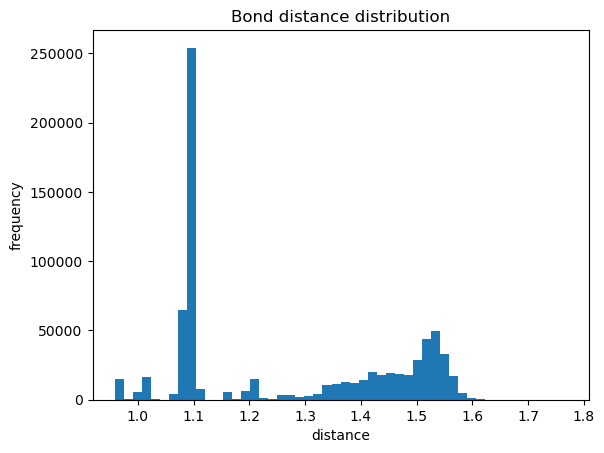

In [43]:
all_distances = []

for g in train_data:
    row, col = g.edge_index
    distances = torch.norm(g.pos[row] - g.pos[col], dim=1)
    all_distances.append(distances)

all_distances = torch.cat(all_distances)

print("Edge distance summary")
print("mean:", all_distances.mean().item())
print("std:", all_distances.std().item())
print("min:", all_distances.min().item())
print("max:", all_distances.max().item())
print("quantiles:", torch.quantile(all_distances, torch.tensor([0.01, 0.05, 0.5, 0.95, 0.99])))

plt.hist(all_distances.numpy(), bins=50)
plt.title("Bond distance distribution")
plt.xlabel("distance")
plt.ylabel("frequency")
plt.show()